# Spatial Region Fits

This is going to be selecting different spatial regions of NGC 604 and plotting their spectra, fitting multiple components if necessary.

In [5]:
%matplotlib widget

from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
from uncertainties import ufloat

plt.rcParams.update({'font.size': 12, 'xtick.minor.visible': True,
                     'ytick.minor.visible': True, 'xtick.direction': 'in',
                     'ytick.direction': 'in',
                     'pgf.texsystem': 'pdflatex',
                     'font.family': 'serif',
                     'text.usetex': True,
                     'pgf.rcfonts': False})

cube = SpectralCube('/Volumes/RayPass/Research/SIGNALS/N604_SN4/3266414z.hdf5')

halpha_map = orb.utils.io.read_fits('/Volumes/RayPass/Research/SIGNALS/Python_N604/NGC604_SN4/MAPS_OneComponent/NGC604_SN4.LineMaps.map.6563.1x1.flux.fits')

region_file = '/Volumes/RayPass/Research/SIGNALS/Python_N604_SN4/data/ngc604sn4.reg'

axis, sky = cube.extract_integrated_spectrum(region_file, median=True, mean_flux=True)

unknown|INFO| Cube is level 3
unknown|WARNING| error reading param from attributes polyref: Insufficient precision in available types to represent (79, 64, 15, 0, 64)
unknown|WARNING| error reading param from attributes polyref: Insufficient precision in available types to represent (79, 64, 15, 0, 64)
unknown|INFO| shape: (2048, 2064, 934)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: True


In [6]:

background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

region_file = '/Volumes/RayPass/Research/SIGNALS/Python_N604_SN4/data/ngc604sn4.reg'

axis, sky = cube.extract_integrated_spectrum(region_file, median=True, mean_flux=True)
#pl.plot(axis, sky)
spectrum = cube.get_spectrum_from_region(region_file, median=False, mean_flux=False)
entire_region = spectrum.subtract_sky(background)

entire_fit2 = entire_region.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

mask = np.isfinite(halpha_map) & (halpha_map > 1e-15)
y, x = np.where(mask)
spectrum = cube.get_spectrum_from_region((y,x), median=False, mean_flux=False)
high_lum = spectrum.subtract_sky(background)

high_lum_fit = high_lum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

# high_lum_fit3 = high_lum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548','Halpha',],
#                         fmodel='sincgaussphased',
#                         pos_def=['1','1','1','2','2','2','3'],
#                         pos_cov=[-214,-180,-230],
#                         sigma_def=['1','1','1','2','2','2','3'],
#                         sigma_cov=[20,20,20],
#                         alpha_cov=[np.pi/20],
#                         alpha_def=['1'])

mask = np.isfinite(halpha_map) & (halpha_map < 1e-15) & (halpha_map > 1e-16)
y, x = np.where(mask)
y1 = y[(y < 1200) & (y > 950) & (x < 1200) & (x > 850)]
x1 = x[(x < 1200) & (x > 850) & (y < 1200) & (y > 950)]

spectrum = cube.get_spectrum_from_region((y1,x1), median=False, mean_flux=False)
low_lum = spectrum.subtract_sky(background)

low_lum_fit = low_lum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

spectrum = cube.get_spectrum(1101.667, 1024.667, 20, median=False, mean_flux=False)
bubbleA = spectrum.subtract_sky(background)

bubbleA_fit2 = bubbleA.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

spectrum = cube.get_spectrum(1086.667, 983.000, 17, median=False, mean_flux=False)
bubbleB = spectrum.subtract_sky(background)

bubbleB_fit2 = bubbleB.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

spectrum = cube.get_spectrum(1010.000, 1036.333, 24, median=False, mean_flux=False)
bubbleC = spectrum.subtract_sky(background)

bubbleC_fit2 = bubbleC.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1','1','1','2','2','2'],
                        pos_cov=[-214,-180],
                        sigma_def=['1','1','1','2','2','2'],
                        sigma_cov=[20,20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

# low_lum_fit3 = low_lum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548','Halpha',],
#                         fmodel='sincgaussphased',
#                         pos_def=['1','1','1','2','2','2','3'],
#                         pos_cov=[-214,-180,-230],
#                         sigma_def=['1','1','1','2','2','2','3'],
#                         sigma_cov=[20,20,20],
#                         alpha_cov=[np.pi/20],
#                         alpha_def=['1'])

# print('=== BIC COMPARISON ===')
# print('if positive and > 2, two component fit is better')
# print("""0 to 2 \t\tNot worth more than a bare mention
# 2 to 6 \t\tPositive
# 6 to 10 \tStrong
# >10 \t\tVery strong """)

# print('DELTA BIC 2 to 3=', high_lum_fit['BIC'] - high_lum_fit3['BIC'])


unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No init

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)

unknown|WARNING| /opt/

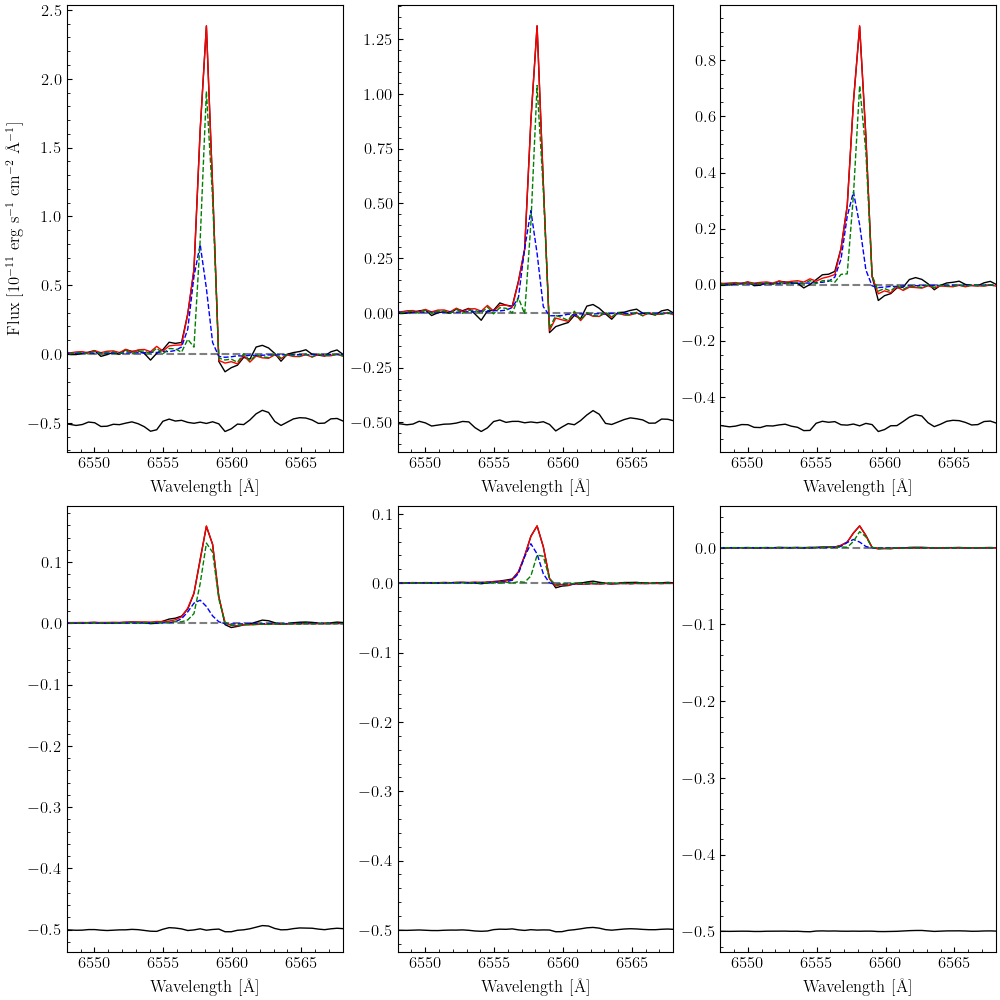

In [110]:
fig = pl.figure(figsize=(10,10), constrained_layout=True)
ax = fig.subplot_mosaic(
    """
    abc
    def
    """
)

for a,s,f in zip(['a','b','c','d','e','f'],
                 [entire_region,high_lum,low_lum,bubbleA,bubbleB,bubbleC],
                 [entire_fit2,high_lum_fit,low_lum_fit,bubbleA_fit2,bubbleB_fit2,bubbleC_fit2]):
    ax[a].plot(1e8/axis, s.data/1e-11, color='k', ls='-', lw=1)
    ax[a].set_xlim((6548,6568))
    ax[a].axhline(0, color='k', ls='--', alpha=0.5)
    ax[a].set_xlabel(r'Wavelength [Å]')
    if a == 'a':
        ax[a].set_ylabel(r'Flux [$10^{-11}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]')

    ax[a].plot(1e8/axis, f.get_spectrum().data/1e-11, c='red', lw=1, ls='-', label='Fit')
    ax[a].plot(1e8/axis, ((s.data - f.get_spectrum().data)/1e-11) - 0.5,
               color='k', ls='-', lw=1)

    i = 0
    comp0 = np.zeros_like(s.data.real)
    comp1 = np.zeros_like(s.data.real)
    comp2 = np.zeros_like(s.data.real)
    for i, imod in zip(range(7), f['fitted_models']['Cm1LinesModel']):
        if i<3: 
            comp0 += imod
        elif i in [3,4,5]: 
            # print(i)
            comp1 += imod
        else: 
            comp2 += imod

    ax[a].plot(1e8/axis, comp0/1e-11, c='blue', lw=1, ls='--')
    ax[a].plot(1e8/axis, comp1/1e-11, c='green', lw=1, ls='--')
    # ax[a].plot(1e8/axis, comp2/1e-11, c='magenta', lw=1, ls='--')

    



In [20]:
def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r" $\times$ 10^" + str(b)

lam0 = 6562.819*(1 + ((-214)/2.998e5))

def wave2vel(x):
    return 2.999e5*((x - lam0)/lam0) + (-214)

def vel2wave(x):
    return ((x - (-214))*lam0)/(2.998e5) + lam0

def compare_components(spectrum, axis):

    fit1 = spectrum.fit(['Halpha', '[NII]6583','[NII]6548'],
                        fmodel='sincgaussphased',
                        pos_def=['1'],
                        pos_cov=[-214],
                        sigma_def=['1'],
                        sigma_cov=[20],
                        alpha_cov=[np.pi/20],
                        alpha_def=['1'])

    # print(fit1)
    fit2 = spectrum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548'],
                            fmodel='sincgaussphased',
                            pos_def=['1','1','1','2','2','2'],
                            pos_cov=[-214,-180],
                            sigma_def=['1','1','1','2','2','2'],
                            sigma_cov=[20,20],
                            alpha_cov=[np.pi/20],
                            alpha_def=['1'])
    
    # print(fit2)
    fit3 = spectrum.fit(['Halpha', '[NII]6583','[NII]6548','Halpha', '[NII]6583','[NII]6548','Halpha',],
                            fmodel='sincgaussphased',
                            pos_def=['1','1','1','2','2','2','3'],
                            pos_cov=[-214,-180,-230],
                            sigma_def=['1','1','1','2','2','2','3'],
                            sigma_cov=[20,20,20],
                            alpha_cov=[np.pi/20],
                            alpha_def=['1'])
    
    # print(fit3)


    fig = plt.figure(figsize=(14,5), constrained_layout=True)
    ax = fig.subplot_mosaic(
        """
        abc
        """)
    
    for a,f in zip(['a','b','c'],[fit1,fit2,fit3]):
        ax[a].plot(1e8/axis, spectrum.data/1e-12, color='k', ls='-', lw=1)
        ax[a].set_xlim((6545,6570))
        ax[a].axhline(0, color='k', ls='--', alpha=0.5)
        ax[a].set_xlabel(r'Wavelength [Å]')
        if a == 'a':
            ax[a].set_ylabel(r'Flux [$10^{-12}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]')

        secax = ax[a].secondary_xaxis('top', functions=(wave2vel,vel2wave))
        secax.set_xlabel(r'Velocity [km/s]')

        y_max = np.nanmax(spectrum.data.real/1e-12) + 0.25*np.nanmax(spectrum.data.real/1e-12)
        y_min = 0 - 0.5*np.nanmax(spectrum.data.real/1e-12)
        ax[a].set_ylim(y_min,y_max)
    
        ax[a].plot(1e8/axis, f.get_spectrum().data/1e-12, c='red', lw=1, ls='-', label='Fit')
        ax[a].plot(1e8/axis, ((spectrum.data - f.get_spectrum().data)/1e-12) - 0.25*np.nanmax(spectrum.data.real/1e-12),
                   color='k', ls='-', lw=1)

        if a == 'a':
            ax[a].set_title(r'One Component')
            flux = ufloat(f['flux'][0],f['flux_err'][0])
            vel = ufloat(f['velocity'][0],f['velocity_err'][0])
            sig = ufloat(f['broadening'][0],f['broadening_err'][0])
            comp_string = '\n'.join((
                r'Component 1:',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s')).format(flux,vel,sig)
            ax[a].text(0.05,0.95,comp_string, transform=ax[a].transAxes, fontsize=10, va='top')
    
        if a == 'b':
            i = 0
            comp0 = np.zeros_like(spectrum.data.real)
            comp1 = np.zeros_like(spectrum.data.real)
            for i, imod in zip(range(6), f['fitted_models']['Cm1LinesModel']):
                if i<3: comp0 += imod
                else: comp1 += imod
    
            ax[a].plot(1e8/axis, comp0/1e-12, c='blue', lw=1, ls='--')
            ax[a].plot(1e8/axis, comp1/1e-12, c='green', lw=1, ls='--')
            ax[a].set_title(r'Two Components')

            flux1 = ufloat(f['flux'][0],f['flux_err'][0])
            vel1 = ufloat(f['velocity'][0],f['velocity_err'][0])
            sig1 = ufloat(f['broadening'][0],f['broadening_err'][0])
            flux2 = ufloat(f['flux'][3],f['flux_err'][3])
            vel2 = ufloat(f['velocity'][3],f['velocity_err'][3])
            sig2 = ufloat(f['broadening'][3],f['broadening_err'][3])
            comp_string = '\n'.join((
                r'Component 1: Blue',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s',
                r'Component 2: Green',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s')).format(flux1,vel1,sig1,flux2,vel2,sig2)
            ax[a].text(0.05,0.95,comp_string, transform=ax[a].transAxes, fontsize=10, va='top')

    
        if a == 'c':
            i = 0
            comp0 = np.zeros_like(spectrum.data.real)
            comp1 = np.zeros_like(spectrum.data.real)
            comp2 = np.zeros_like(spectrum.data.real)
            for i, imod in zip(range(7), f['fitted_models']['Cm1LinesModel']):
                if i<3: 
                    comp0 += imod
                elif i in [3,4,5]: 
                    # print(i)
                    comp1 += imod
                else: 
                    comp2 += imod
        
            ax[a].plot(1e8/axis, comp0/1e-12, c='blue', lw=1, ls='--')
            ax[a].plot(1e8/axis, comp1/1e-12, c='green', lw=1, ls='--')
            ax[a].plot(1e8/axis, comp2/1e-12, c='magenta', lw=1, ls='--')
            ax[a].set_title(r'Three Components')

            flux1 = ufloat(f['flux'][0],f['flux_err'][0])
            vel1 = ufloat(f['velocity'][0],f['velocity_err'][0])
            sig1 = ufloat(f['broadening'][0],f['broadening_err'][0])
            flux2 = ufloat(f['flux'][3],f['flux_err'][3])
            vel2 = ufloat(f['velocity'][3],f['velocity_err'][3])
            sig2 = ufloat(f['broadening'][3],f['broadening_err'][3])
            flux3 = ufloat(f['flux'][6],f['flux_err'][6])
            vel3 = ufloat(f['velocity'][6],f['velocity_err'][6])
            sig3 = ufloat(f['broadening'][6],f['broadening_err'][6])
            comp_string = '\n'.join((
                r'Component 1: Blue',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s',
                r'Component 2: Green',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s',
                r'Component 3: Magenta',
                r'$F = $ {:.2u} erg/s/cm$^{{2}}$',
                r'$V = $ {:.2u} km/s',
                r'$\sigma = $ {:.2u} km/s')).format(flux1,vel1,sig1,flux2,vel2,sig2,flux3,vel3,sig3)
            ax[a].text(0.05,0.95,comp_string, transform=ax[a].transAxes, fontsize=10, va='top')
    
        
    print('=== BIC COMPARISON ===')
    print('if positive and > 2, two component fit is better')
    print("""0 to 2 \t\tNot worth more than a bare mention
2 to 6 \t\tPositive
6 to 10 \tStrong
>10 \t\tVery strong """)
    
    print('DELTA BIC 1 to 2=', fit1['BIC'] - fit2['BIC'])
    print('DELTA BIC 2 to 3=', fit2['BIC'] - fit3['BIC'])

    return fit1, fit2, fit3
    

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 134.64326082018852
DELTA BIC 2 to 3= -9.895019323572342


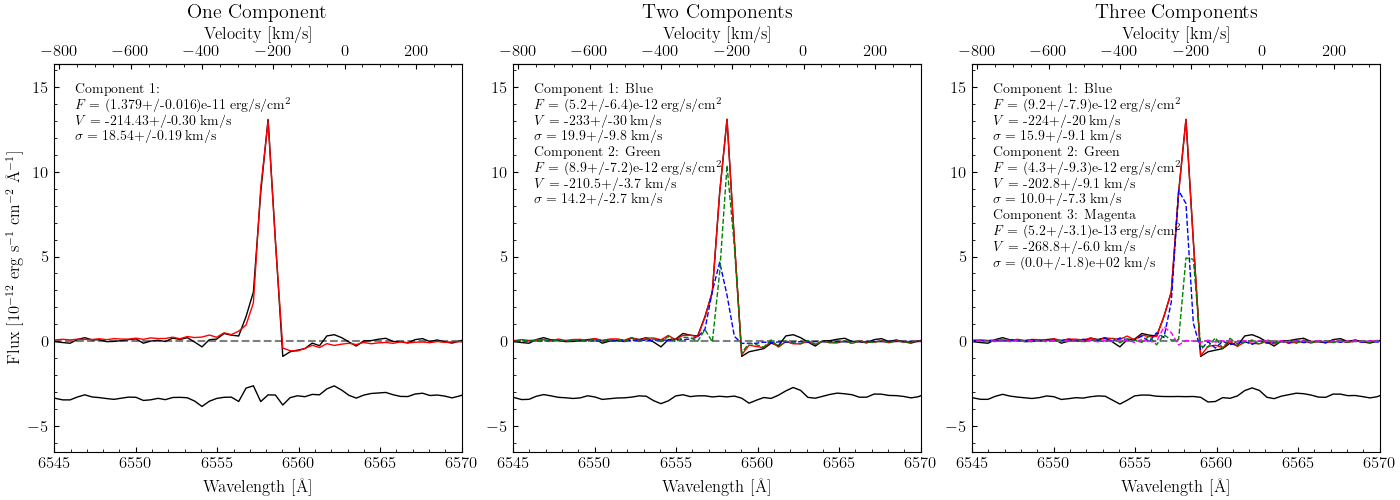

In [21]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

region_file = '/Volumes/RayPass/Research/SIGNALS/N604_SN4/ngc604sn4.reg'

mask = np.isfinite(halpha_map) & (halpha_map > 1e-15)
y, x = np.where(mask)
spectrum = cube.get_spectrum_from_region((y,x), median=False, mean_flux=False)
high_lum = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(high_lum,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 130.55002511124803
DELTA BIC 2 to 3= -4.549618822635239


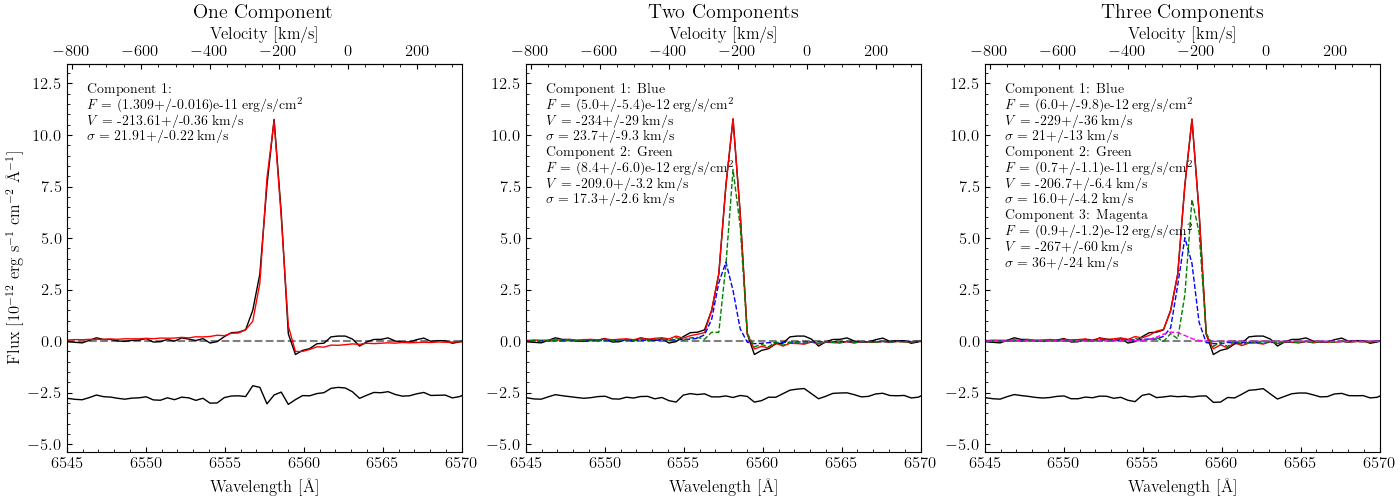

In [31]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

region_file = '/Volumes/RayPass/Research/SIGNALS/N604_SN4/ngc604sn4.reg'

mask = np.isfinite(halpha_map) & (halpha_map < 1e-15) & (halpha_map > 1e-17)
y, x = np.where(mask)
y1 = y[(y < 1200) & (y > 950) & (x < 1200) & (x > 850)]
x1 = x[(x < 1200) & (x > 850) & (y < 1200) & (y > 950)]

spectrum = cube.get_spectrum_from_region((y1,x1), median=False, mean_flux=False)
low_lum = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(low_lum,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 124.54252604904832
DELTA BIC 2 to 3= 18.993363908954052


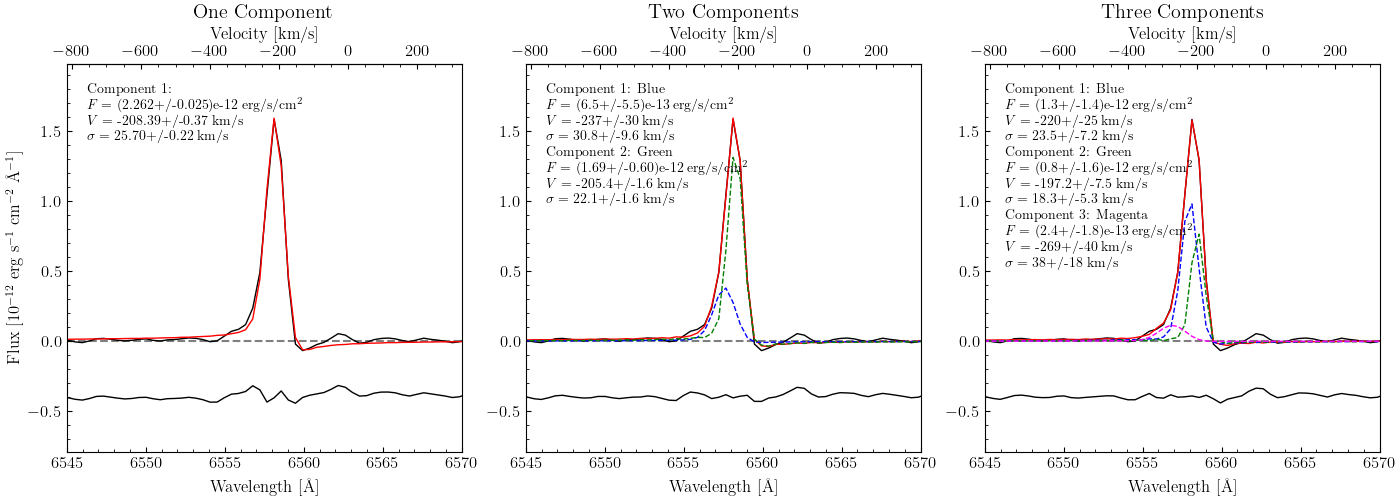

In [23]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(1101.667, 1024.667, 20, median=False, mean_flux=False)
bubbleA = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(bubbleA,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 182.15076345026864
DELTA BIC 2 to 3= -13.999509857207158


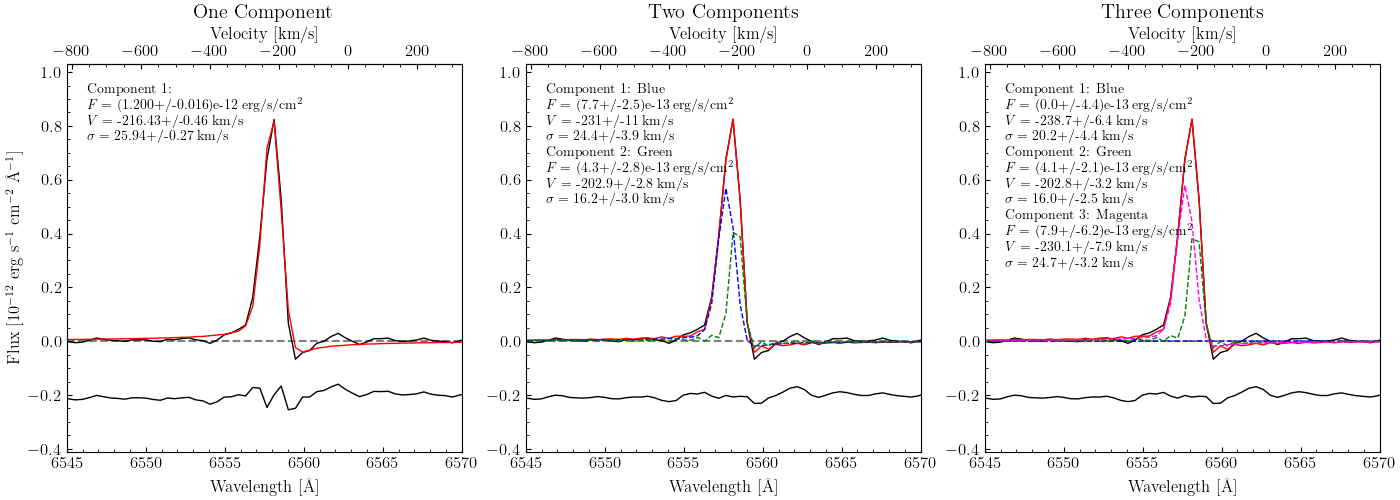

In [24]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(1086.667, 983.000, 17, median=False, mean_flux=False)
bubbleB = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(bubbleB,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 117.39243991102558
DELTA BIC 2 to 3= -8.44960966637882


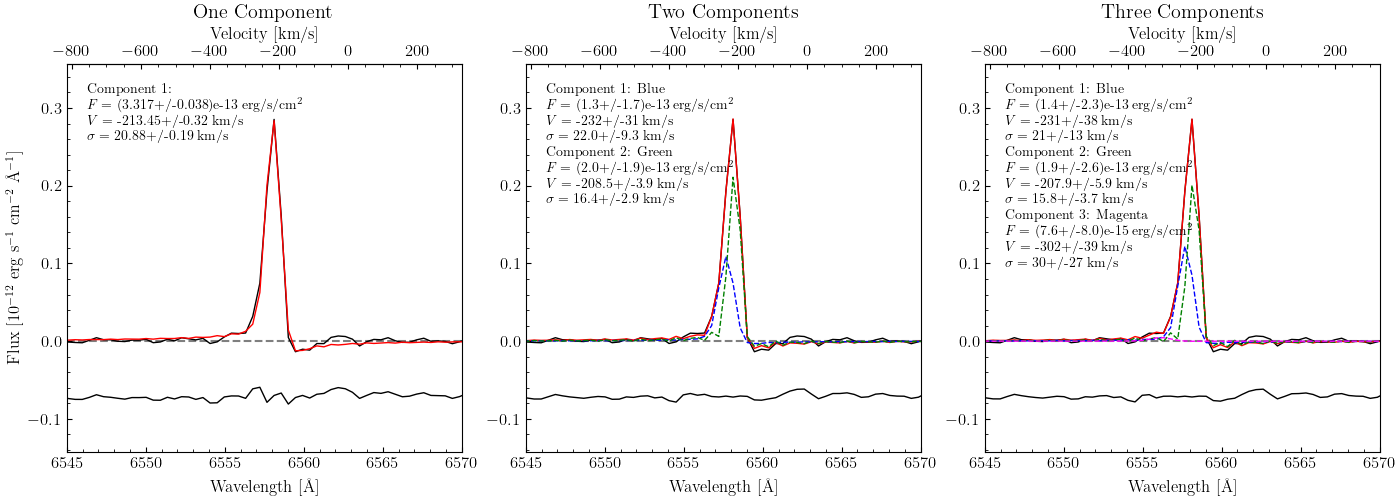

In [25]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(1010.000, 1036.333, 24, median=False, mean_flux=False)
bubbleC = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(bubbleC,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 435.05916664053075
DELTA BIC 2 to 3= 96.59143317845519


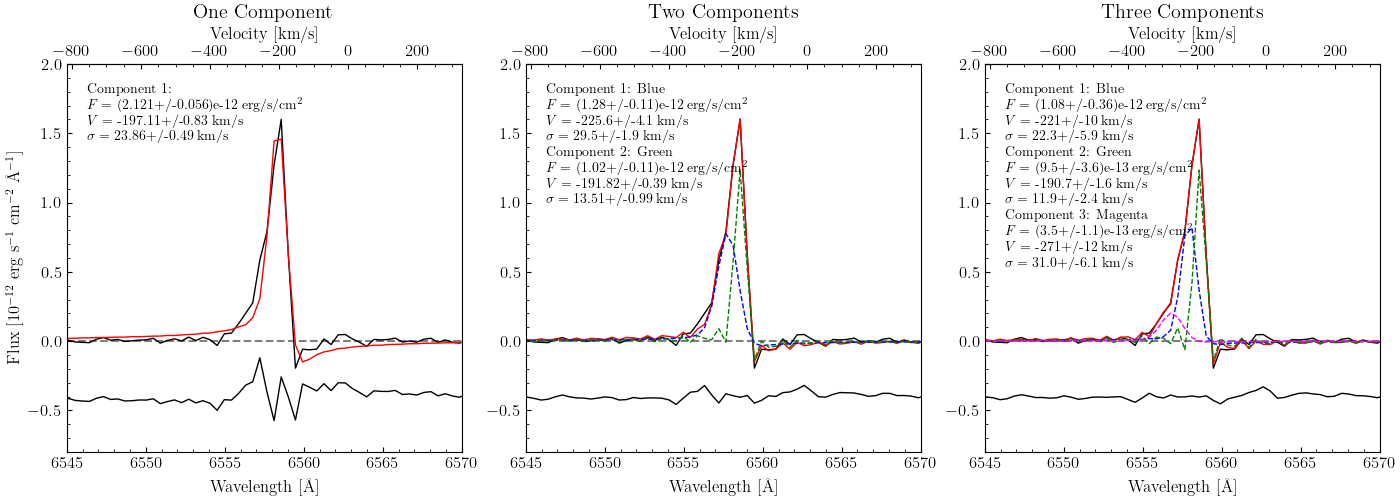

In [28]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(1088.194, 1060.778, 34, median=False, mean_flux=False)
bubbleD = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(bubbleD,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 155.5627115039715
DELTA BIC 2 to 3= -5.691436262375646


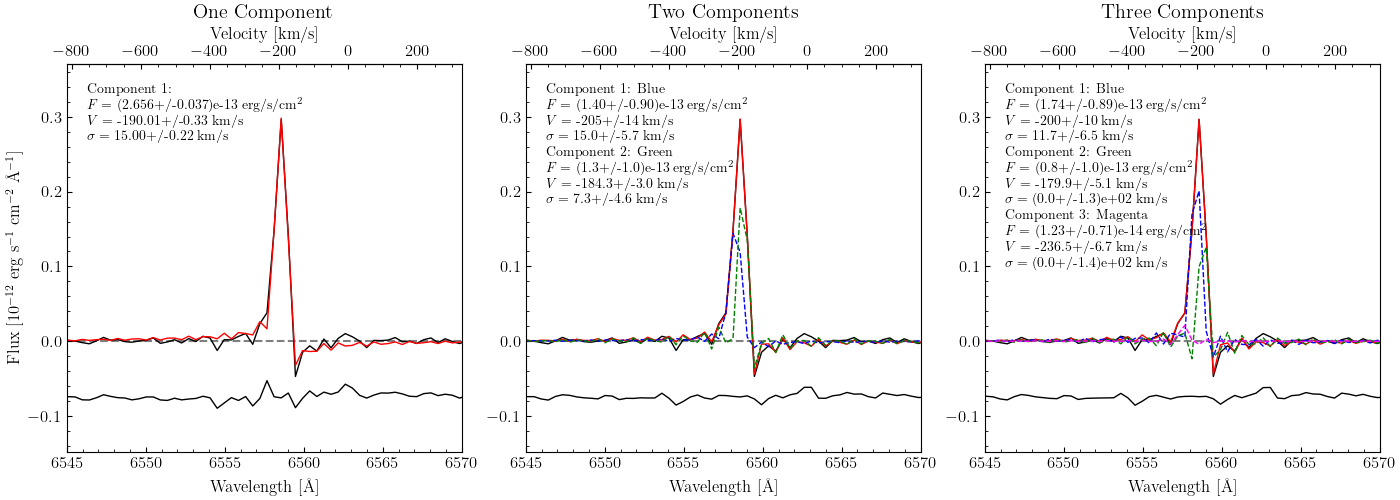

In [29]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(977.083, 969.806, 21, median=False, mean_flux=False)
east_outflow = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(east_outflow,axis)

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)

unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| No initial alpha given
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized argu

=== BIC COMPARISON ===
if positive and > 2, two component fit is better
0 to 2 		Not worth more than a bare mention
2 to 6 		Positive
6 to 10 	Strong
>10 		Very strong 
DELTA BIC 1 to 2= 330.9636163478972
DELTA BIC 2 to 3= 93.71441303851316


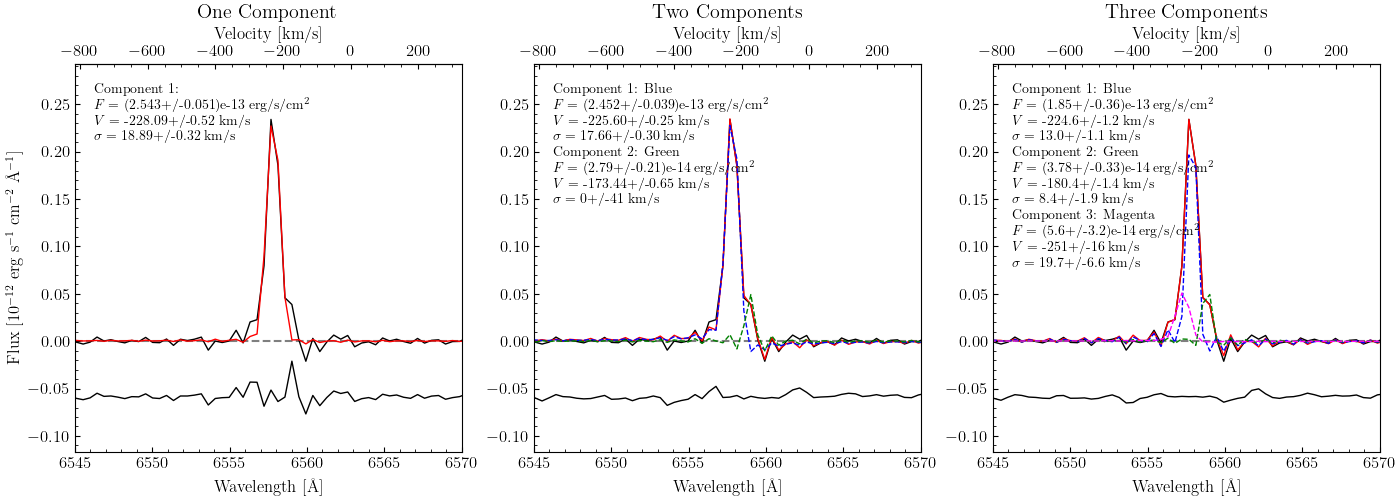

In [47]:
background = cube.get_spectrum_in_annulus(331,1374,1,40, median=True, mean_flux=True)

spectrum = cube.get_spectrum(1096.105, 1014.875, 5, median=False, mean_flux=False)
north = spectrum.subtract_sky(background)

fit1,fit2,fit3 = compare_components(north,axis)

In [33]:
from astropy.coordinates import SkyCoord
import astropy.units as u

coord = SkyCoord('1h34m33.11s', '+30d47m6.8s', unit=(u.hourangle,u.deg))

In [36]:
coord

<SkyCoord (ICRS): (ra, dec) in deg
    (23.63795833, 30.78522222)>

In [41]:
(coord.ra - (5 * u.arcsec)).to(u.deg)

<Angle 23.63656944 deg>

In [40]:
coord.dec - (36 * u.arcsec)

<Angle 30.77522222 deg>

In [42]:
23 + (38/60) + (11.65/3600)

23.636569444444444

In [43]:
30 + (46/60) + (30.8/3600)

30.775222222222222